Exploratory Data Mining of Air Traffic Patterns for Improved Flight Management

***Project Overview***

This project applies data mining techniques to analyze flight operations data, aiming to discover hidden patterns and provide actionable insights for optimizing air traffic management.

## Phase 1: Business Understanding

This phase establishes the foundation for our data mining project by:

1. **Defining Business Objectives**: What the organization wants to achieve
2. **Assessing Situation**: Resources, constraints, and requirements
3. **Setting Data Mining Goals**: Translating business needs into technical objectives


In [3]:
# ============================================================================
# PHASE 1: BUSINESS UNDERSTANDING
# ============================================================================
print("\n" + "="*80)
print("PHASE 1: BUSINESS UNDERSTANDING")
print("="*80)

business_objectives = """
BUSINESS OBJECTIVES:

1. OPERATIONAL EFFICIENCY:
   • Reduce flight delays and cancellations
   • Optimize resource allocation (gates, terminals, staff)
   • Improve on-time performance

2. NETWORK OPTIMIZATION:
   • Identify profitable and problematic routes
   • Optimize flight schedules and connections
   • Enhance passenger experience

3. RISK MANAGEMENT:
   • Identify patterns leading to disruptions
   • Develop proactive maintenance schedules
   • Improve contingency planning

4. CUSTOMER SATISFACTION:
   • Minimize passenger inconvenience
   • Improve service reliability
   • Enhance brand reputation

DATA MINING GOALS:

1. CLUSTERING:
   • Group similar flight patterns for targeted management

2. ASSOCIATION RULES:
   • Discover relationships between delays, routes, and times
   • Find patterns: "If X happens, then Y is likely"
"""

print(business_objectives)
print("✓ Phase 1 Complete: Business understanding documented")


PHASE 1: BUSINESS UNDERSTANDING

BUSINESS OBJECTIVES:

1. OPERATIONAL EFFICIENCY:
   • Reduce flight delays and cancellations
   • Optimize resource allocation (gates, terminals, staff)
   • Improve on-time performance

2. NETWORK OPTIMIZATION:
   • Identify profitable and problematic routes
   • Optimize flight schedules and connections
   • Enhance passenger experience

3. RISK MANAGEMENT:
   • Identify patterns leading to disruptions
   • Develop proactive maintenance schedules
   • Improve contingency planning

4. CUSTOMER SATISFACTION:
   • Minimize passenger inconvenience
   • Improve service reliability
   • Enhance brand reputation

DATA MINING GOALS:

1. CLUSTERING:
   • Group similar flight patterns for targeted management

2. ASSOCIATION RULES:
   • Discover relationships between delays, routes, and times
   • Find patterns: "If X happens, then Y is likely"

✓ Phase 1 Complete: Business understanding documented


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
# ============================================================================
# project setup
# ============================================================================
import pandas as pd
import numpy as np
import json
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("="*80)
print("EXPLORATORY DATA MINING OF AIR TRAFFIC PATTERNS")
print("FOR IMPROVED FLIGHT MANAGEMENT")
print("="*80)

from google.colab import files

print("\n" + "="*80)
print("STEP 1: UPLOAD AND EXTRACT DATA")
print("="*80)

print("\n Please upload your 'data.zip' file...")
uploaded = files.upload()

# Extract the zip file
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f"\n Extracting {filename}...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(" Extraction complete!")

print("\n Checking extracted files...")
print(os.listdir('.'))

# ========== SECTION 4: LOAD DATA ==========
print("\n" + "="*80)
print("STEP 2: LOAD AND VERIFY DATA")
print("="*80)

# Load CodeContext
with open('data/CodeContexte.json', 'r') as f:
    code_context = json.load(f)
print(f"✓ Loaded CodeContext: {len(code_context)} status codes")

# Load flight data
with open('data/allflight.json', 'r') as f:
    all_data = json.load(f)
df = pd.DataFrame(all_data)
print(f" Loaded {len(df):,} flight records")

print("\n" + "="*80)
print(" SETUP COMPLETE - READY FOR ANALYSIS")
print("="*80)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

EXPLORATORY DATA MINING OF AIR TRAFFIC PATTERNS
FOR IMPROVED FLIGHT MANAGEMENT

STEP 1: UPLOAD AND EXTRACT DATA

 Please upload your 'data.zip' file...


Saving data.zip to data (1).zip

 Extracting data (1).zip...
 Extraction complete!

 Checking extracted files...
['.config', 'data', 'data.zip', 'association_rules_network.png', 'domestic_vs_international.png', 'data (1).zip', 'cluster_performance.png', 'cluster_analysis_summary.png', 'peak_hours_discovery.png', 'time_performance_heatmap.png', 'elbow_method.png', 'cluster_distribution.png', 'sample_data']

STEP 2: LOAD AND VERIFY DATA
✓ Loaded CodeContext: 16 status codes
 Loaded 157,718 flight records

 SETUP COMPLETE - READY FOR ANALYSIS


## Phase 2: Data Understanding

In this phase, we:
- Collect and explore the initial data
- Identify data quality issues
- Discover first insights about the data
- Verify data quality

We'll examine the flight data structure, check for missing values, and understand the basic statistics of our dataset.

In [5]:
import pandas as pd
import numpy as np
import json
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings


# ============================================================================
# PHASE 2: DATA UNDERSTANDING
# ============================================================================
print("\n" + "="*80)
print("PHASE 2: DATA UNDERSTANDING")
print("="*80)

# Load the data (based on your previous work)
print("Loading data files...")

# Load CodeContext
with open('data/CodeContexte.json', 'r') as f:
    code_context = json.load(f)

print(f" Loaded CodeContext: {len(code_context)} status codes")

# Load flight data
with open('data/allflight.json', 'r') as f:
    all_data = json.load(f)

df = pd.DataFrame(all_data)
print(f" Loaded {len(df):,} flight records")

# Display basic information
print("\n DATASET OVERVIEW:")
print(f"• Shape: {df.shape}")
print(f"• Columns: {list(df.columns)}")
print(f"• Date range: {df['origindate'].min()} to {df['origindate'].max()}")

# Check data types and missing values
print("\n DATA QUALITY CHECK:")
print("Missing values per column:")
missing_df = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_df[missing_df['Missing'] > 0])
if missing_df['Missing'].sum() == 0:
    print(" No missing values found!")

print("\n DATA TYPES:")
print(df.dtypes)

# Create initial route column
df['route'] = df['departureairport'] + '-' + df['arrivalairport']

# Convert dates
df['operationtime'] = pd.to_datetime(df['operationtime'])
df['origindate'] = pd.to_datetime(df['origindate'])

print("\n Phase 2 Complete: Data understanding established")


PHASE 2: DATA UNDERSTANDING
Loading data files...
 Loaded CodeContext: 16 status codes
 Loaded 157,718 flight records

 DATASET OVERVIEW:
• Shape: (157718, 9)
• Columns: ['operationtime', 'airline', 'flightnumber', 'departureairport', 'arrivalairport', 'aircraftterminal', 'departureorarrival', 'origindate', 'CodeContext']
• Date range: 2021-12-29 to 2024-12-05

 DATA QUALITY CHECK:
Missing values per column:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []
 No missing values found!

 DATA TYPES:
operationtime         object
airline               object
flightnumber          object
departureairport      object
arrivalairport        object
aircraftterminal      object
departureorarrival    object
origindate            object
CodeContext           object
dtype: object

 Phase 2 Complete: Data understanding established


simple data exploration

In [6]:

print("DATASET EXPLORATION")
print("=" * 60)

print(f"Total flights: {len(df):,}")
print(f"Date range: {df['origindate'].min()} to {df['origindate'].max()}")

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Basic statistics
print("\nUnique values per column:")
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"  {column:20}: {unique_count:>6} unique values")

# Status distribution
print("\nFlight Status Distribution:")
status_counts = df['CodeContext'].value_counts()
for status, count in status_counts.items():
    status_name = code_context.get(status, "Unknown")
    percentage = (count / len(df)) * 100
    print(f"  {status:4} ({status_name:15}): {count:>7,} flights ({percentage:5.1f}%)")

# Airlines and airports
print(f"\nNumber of airlines: {df['airline'].nunique()}")
print(f"Number of airports (departure): {df['departureairport'].nunique()}")
print(f"Number of airports (arrival): {df['arrivalairport'].nunique()}")

DATASET EXPLORATION
Total flights: 157,718
Date range: 2021-12-29 00:00:00 to 2024-12-05 00:00:00

Missing values per column:
operationtime         0
airline               0
flightnumber          0
departureairport      0
arrivalairport        0
aircraftterminal      0
departureorarrival    0
origindate            0
CodeContext           0
route                 0
dtype: int64

Unique values per column:
  operationtime       : 117125 unique values
  airline             :     43 unique values
  flightnumber        :   2447 unique values
  departureairport    :    158 unique values
  arrivalairport      :    163 unique values
  aircraftterminal    :     12 unique values
  departureorarrival  :      2 unique values
  origindate          :    813 unique values
  CodeContext         :      8 unique values
  route               :    320 unique values

Flight Status Distribution:
  ONB  (arrived        ):  65,543 flights ( 41.6%)
  OFB  (departed       ):  64,140 flights ( 40.7%)
  SCT  (on ti

VISUALIZATION 1: Flight Status Distribution

VISUALIZATION 2: Top 10 Airlines

VISUALIZATION 3: Top 10 Routes


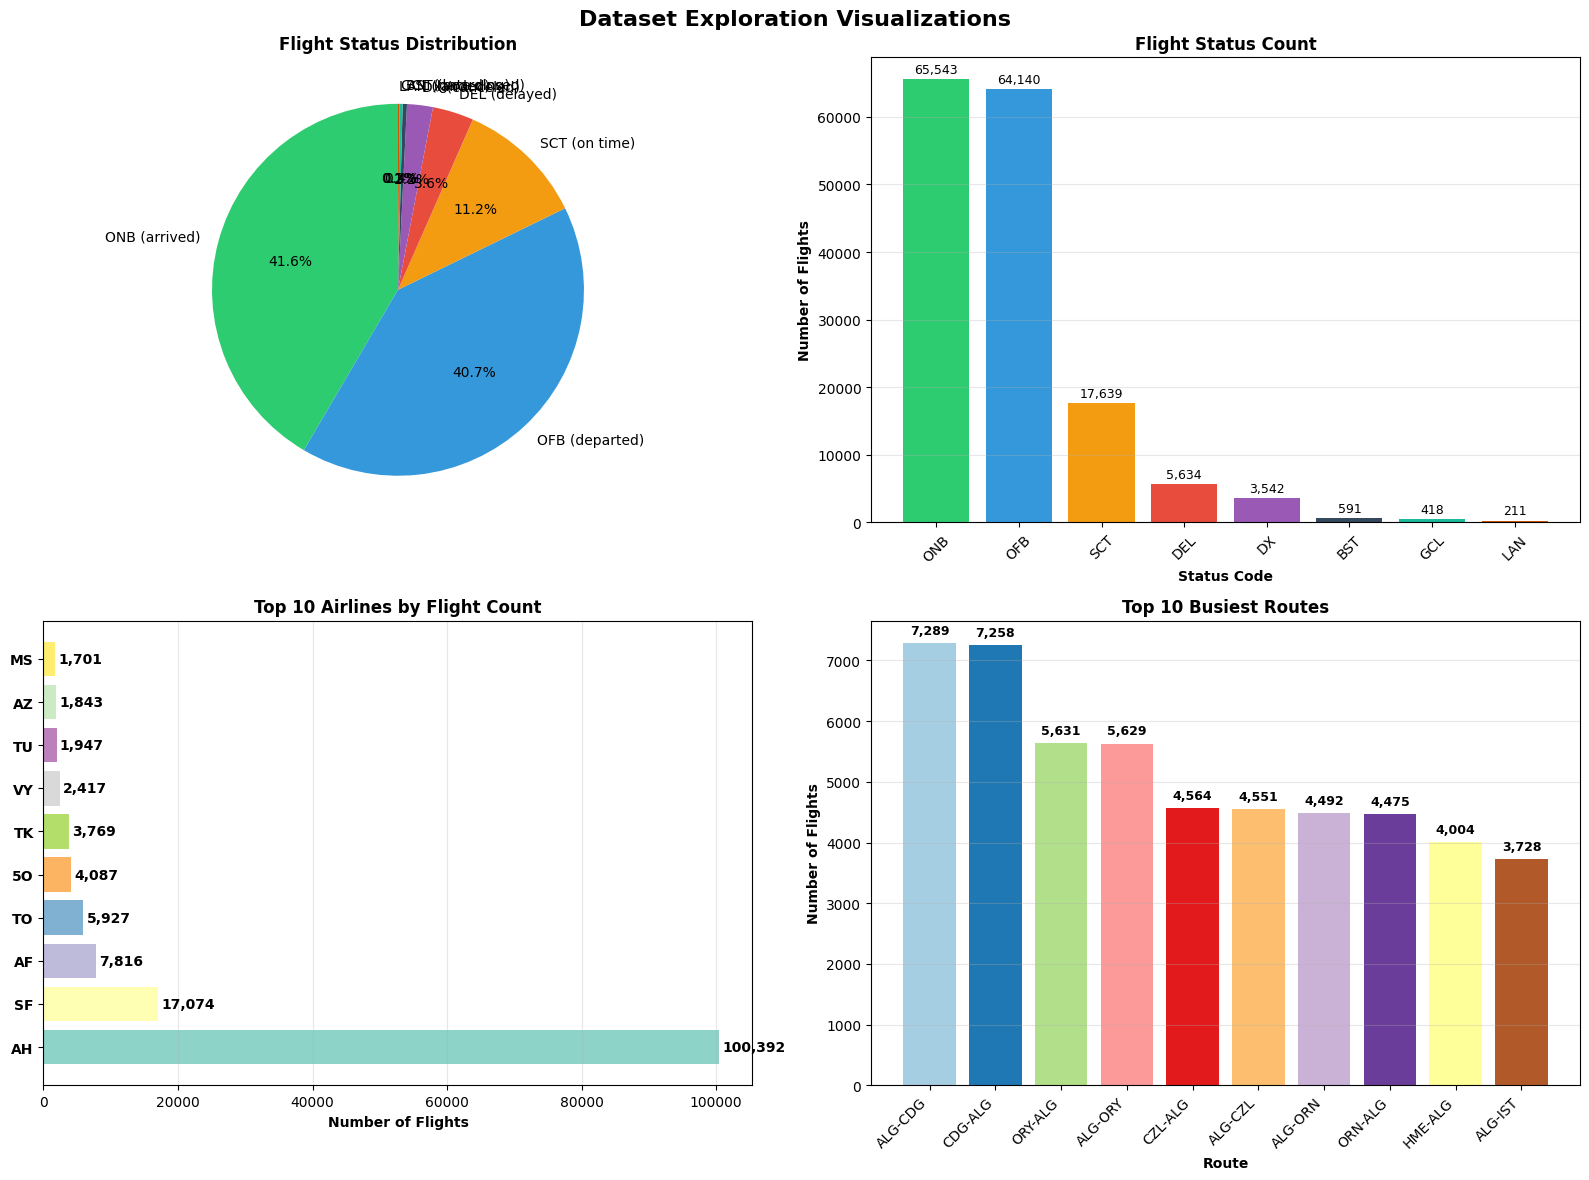


VISUALIZATION 4: Airport Analysis

VISUALIZATION 5: Hourly Flight Distribution

VISUALIZATION 6: Dataset Summary Statistics


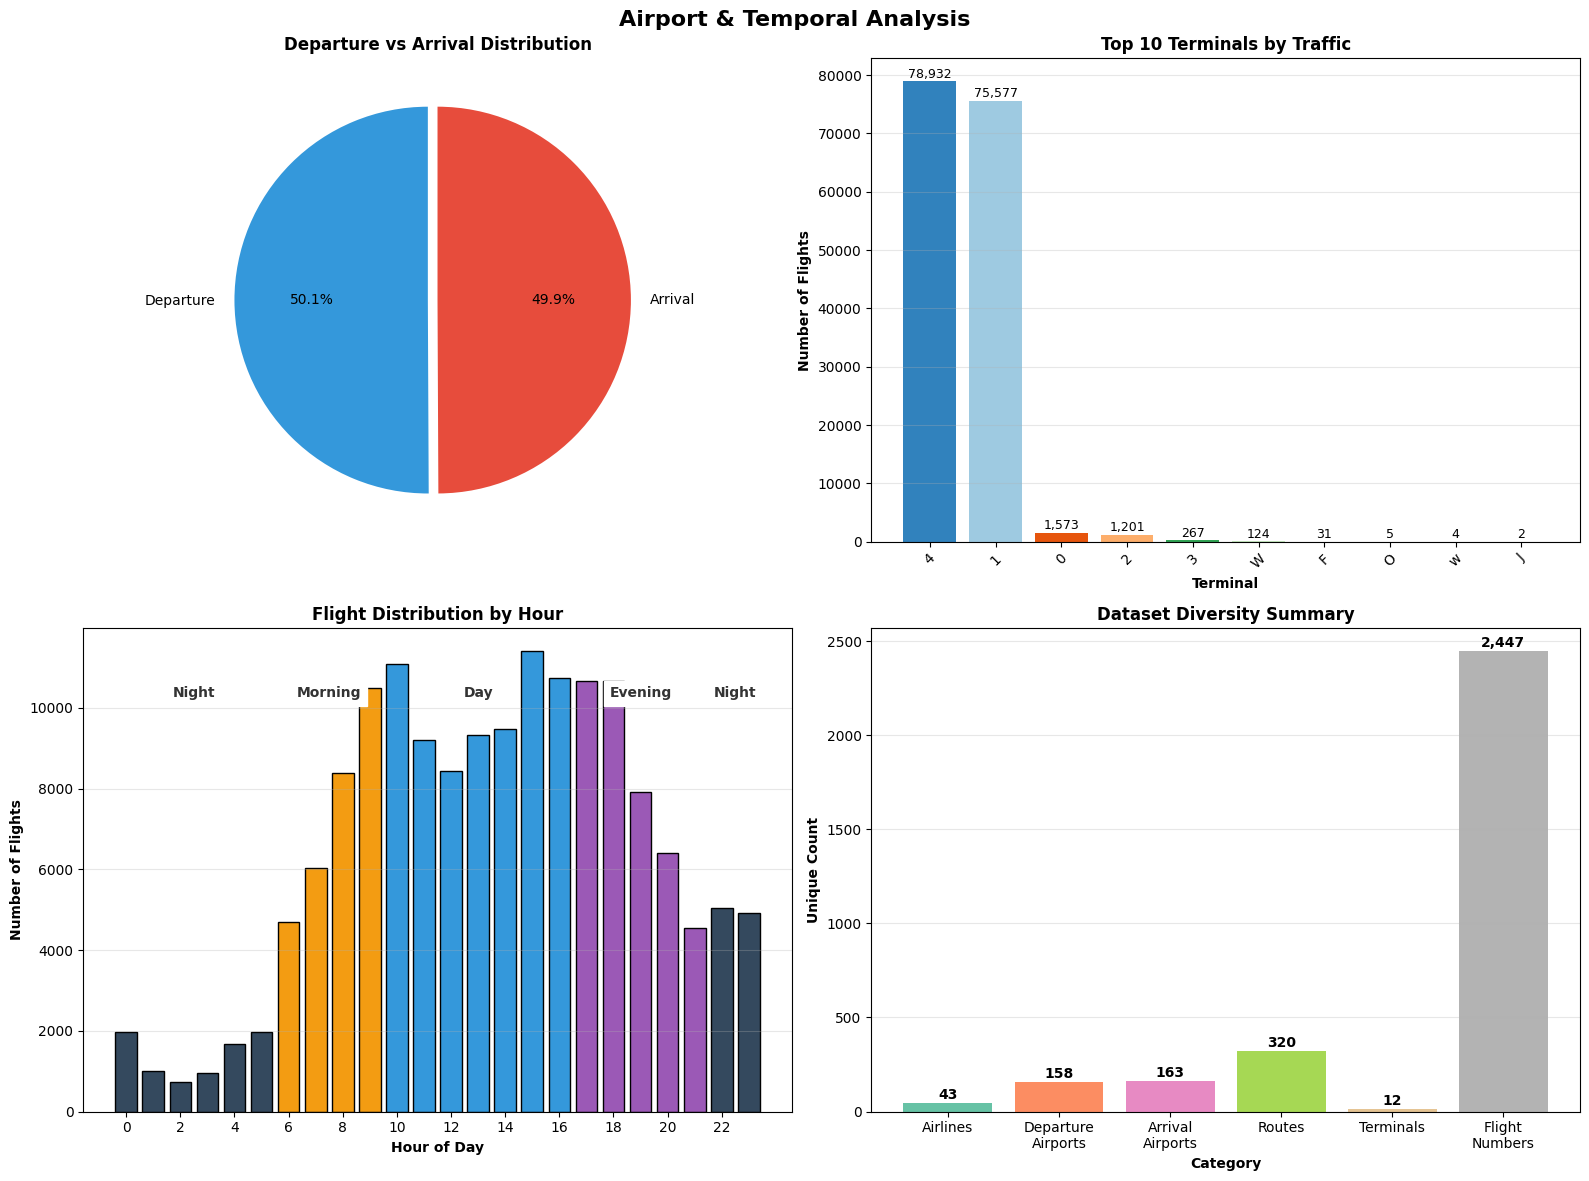


VISUALIZATION 7: Detailed Flight Status Analysis


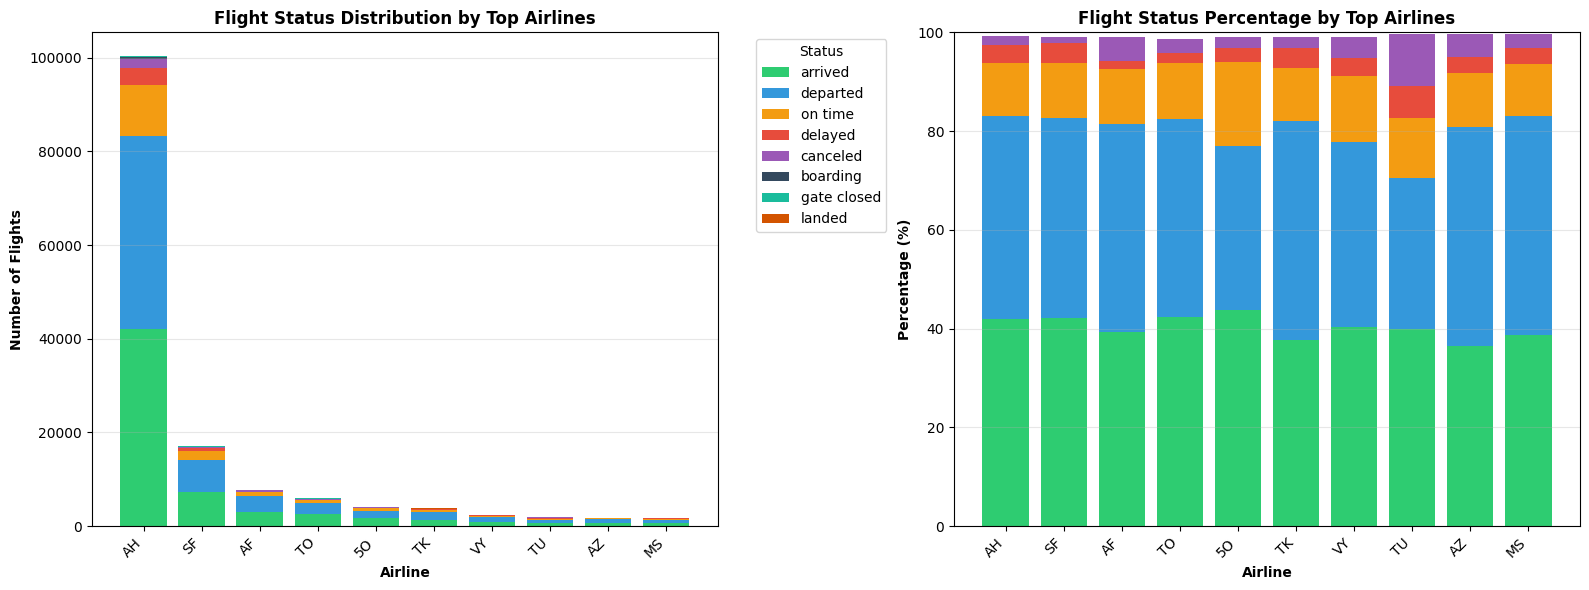


ALL VISUALIZATIONS COMPLETE!
3 image files saved:
1. dataset_exploration_overview.png
2. airport_temporal_analysis.png
3. status_by_airline_analysis.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# Set style
plt.style.use('default')
sns.set_palette("husl")

# 1. FLIGHT STATUS DISTRIBUTION
print("="*60)
print("VISUALIZATION 1: Flight Status Distribution")
print("="*60)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dataset Exploration Visualizations', fontsize=16, fontweight='bold')

# Status Distribution Pie Chart
status_counts = df['CodeContext'].value_counts()
status_labels = [f"{code} ({code_context.get(code, 'Unknown')})"
                for code in status_counts.index]

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#34495e', '#1abc9c', '#d35400']
ax1.pie(status_counts.values, labels=status_labels, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title('Flight Status Distribution', fontweight='bold')

# Status Distribution Bar Chart
bars = ax2.bar(range(len(status_counts)), status_counts.values, color=colors)
ax2.set_xlabel('Status Code', fontweight='bold')
ax2.set_ylabel('Number of Flights', fontweight='bold')
ax2.set_title('Flight Status Count', fontweight='bold')
ax2.set_xticks(range(len(status_counts)))
ax2.set_xticklabels(status_counts.index, rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, status_counts.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{count:,}', ha='center', va='bottom', fontsize=9)

# 2. TOP 10 AIRLINES
print("\nVISUALIZATION 2: Top 10 Airlines")
top_airlines = df['airline'].value_counts().head(10)
colors_airlines = plt.cm.Set3(np.linspace(0, 1, len(top_airlines)))
bars_air = ax3.barh(range(len(top_airlines)), top_airlines.values, color=colors_airlines)
ax3.set_yticks(range(len(top_airlines)))
ax3.set_yticklabels(top_airlines.index, fontweight='bold')
ax3.set_xlabel('Number of Flights', fontweight='bold')
ax3.set_title('Top 10 Airlines by Flight Count', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Add value labels
for i, (airline, count) in enumerate(top_airlines.items()):
    ax3.text(count + 500, i, f'{count:,}', va='center', fontweight='bold')

# 3. TOP 10 ROUTES
print("\nVISUALIZATION 3: Top 10 Routes")
top_routes = df['route'].value_counts().head(10)
colors_routes = plt.cm.Paired(np.linspace(0, 1, len(top_routes)))

# Truncate long route names for display
route_labels = [route if len(route) <= 20 else route[:17] + '...'
                for route in top_routes.index]

bars_routes = ax4.bar(range(len(top_routes)), top_routes.values, color=colors_routes)
ax4.set_xlabel('Route', fontweight='bold')
ax4.set_ylabel('Number of Flights', fontweight='bold')
ax4.set_title('Top 10 Busiest Routes', fontweight='bold')
ax4.set_xticks(range(len(top_routes)))
ax4.set_xticklabels(route_labels, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars_routes, top_routes.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_exploration_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. DETAILED AIRPORT ANALYSIS
print("\n" + "="*60)
print("VISUALIZATION 4: Airport Analysis")
print("="*60)

fig2, ((ax5, ax6), (ax7, ax8)) = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('Airport & Temporal Analysis', fontsize=16, fontweight='bold')

# Departure vs Arrival Distribution
arr_dep_counts = df['departureorarrival'].value_counts()
colors_ad = ['#3498db', '#e74c3c']
ax5.pie(arr_dep_counts.values, labels=arr_dep_counts.index, autopct='%1.1f%%',
        colors=colors_ad, startangle=90, explode=(0.05, 0))
ax5.set_title('Departure vs Arrival Distribution', fontweight='bold')

# Terminal Distribution
terminal_counts = df['aircraftterminal'].value_counts().head(10)
colors_terminal = plt.cm.tab20c(np.linspace(0, 1, len(terminal_counts)))
bars_term = ax6.bar(range(len(terminal_counts)), terminal_counts.values, color=colors_terminal)
ax6.set_xlabel('Terminal', fontweight='bold')
ax6.set_ylabel('Number of Flights', fontweight='bold')
ax6.set_title('Top 10 Terminals by Traffic', fontweight='bold')
ax6.set_xticks(range(len(terminal_counts)))
ax6.set_xticklabels(terminal_counts.index, rotation=45)
ax6.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars_term, terminal_counts.values):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{count:,}', ha='center', va='bottom', fontsize=9)

# 5. TEMPORAL ANALYSIS - Hourly Distribution
print("\nVISUALIZATION 5: Hourly Flight Distribution")
df['hour'] = pd.to_datetime(df['operationtime']).dt.hour
hourly_counts = df['hour'].value_counts().sort_index()

# Create gradient colors for hours
hour_colors = []
for hour in hourly_counts.index:
    if 6 <= hour <= 9:  # Morning
        hour_colors.append('#f39c12')
    elif 10 <= hour <= 16:  # Day
        hour_colors.append('#3498db')
    elif 17 <= hour <= 21:  # Evening
        hour_colors.append('#9b59b6')
    else:  # Night
        hour_colors.append('#34495e')

bars_hour = ax7.bar(hourly_counts.index, hourly_counts.values, color=hour_colors, edgecolor='black')
ax7.set_xlabel('Hour of Day', fontweight='bold')
ax7.set_ylabel('Number of Flights', fontweight='bold')
ax7.set_title('Flight Distribution by Hour', fontweight='bold')
ax7.set_xticks(range(0, 24, 2))
ax7.grid(axis='y', alpha=0.3)

# Add time period labels
time_periods = [(0, 5, 'Night'), (6, 9, 'Morning'), (10, 16, 'Day'), (17, 21, 'Evening'), (22, 23, 'Night')]
for start, end, label in time_periods:
    if start <= end:
        ax7.text((start + end) / 2, hourly_counts.max() * 0.9, label,
                ha='center', fontweight='bold', fontsize=10, backgroundcolor='white', alpha=0.8)

# 6. UNIQUE COUNTS SUMMARY
print("\nVISUALIZATION 6: Dataset Summary Statistics")
categories = ['Airlines', 'Departure\nAirports', 'Arrival\nAirports', 'Routes', 'Terminals', 'Flight\nNumbers']
counts = [df['airline'].nunique(),
          df['departureairport'].nunique(),
          df['arrivalairport'].nunique(),
          df['route'].nunique(),
          df['aircraftterminal'].nunique(),
          df['flightnumber'].nunique()]

colors_summary = plt.cm.Set2(np.linspace(0, 1, len(categories)))
bars_summary = ax8.bar(range(len(categories)), counts, color=colors_summary)
ax8.set_xlabel('Category', fontweight='bold')
ax8.set_ylabel('Unique Count', fontweight='bold')
ax8.set_title('Dataset Diversity Summary', fontweight='bold')
ax8.set_xticks(range(len(categories)))
ax8.set_xticklabels(categories, rotation=0)
ax8.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars_summary, counts):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('airport_temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. FLIGHT STATUS DETAILED BREAKDOWN
print("\n" + "="*60)
print("VISUALIZATION 7: Detailed Flight Status Analysis")
print("="*60)

fig3, (ax9, ax10) = plt.subplots(1, 2, figsize=(16, 6))

# Status by Airline (Top 10)
top_airlines_list = top_airlines.index.tolist()
status_by_airline = df[df['airline'].isin(top_airlines_list)].groupby(['airline', 'CodeContext']).size().unstack(fill_value=0)

colors_status = {'ONB': '#2ecc71', 'OFB': '#3498db', 'SCT': '#f39c12',
                 'DEL': '#e74c3c', 'DX': '#9b59b6', 'BST': '#34495e',
                 'GCL': '#1abc9c', 'LAN': '#d35400'}

bottom = np.zeros(len(top_airlines_list))
for status in ['ONB', 'OFB', 'SCT', 'DEL', 'DX', 'BST', 'GCL', 'LAN']:
    if status in status_by_airline.columns:
        counts = status_by_airline[status].reindex(top_airlines_list).fillna(0).values
        ax9.bar(range(len(top_airlines_list)), counts, bottom=bottom,
                label=code_context.get(status, status), color=colors_status.get(status, 'gray'))
        bottom += counts

ax9.set_xlabel('Airline', fontweight='bold')
ax9.set_ylabel('Number of Flights', fontweight='bold')
ax9.set_title('Flight Status Distribution by Top Airlines', fontweight='bold')
ax9.set_xticks(range(len(top_airlines_list)))
ax9.set_xticklabels(top_airlines_list, rotation=45, ha='right')
ax9.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax9.grid(axis='y', alpha=0.3)

# Status Percentage by Airline
status_percentages = (status_by_airline.div(status_by_airline.sum(axis=1), axis=0) * 100)

bottom_pct = np.zeros(len(top_airlines_list))
for status in ['ONB', 'OFB', 'SCT', 'DEL', 'DX']:
    if status in status_percentages.columns:
        percentages = status_percentages[status].reindex(top_airlines_list).fillna(0).values
        ax10.bar(range(len(top_airlines_list)), percentages, bottom=bottom_pct,
                 label=code_context.get(status, status), color=colors_status.get(status, 'gray'))
        bottom_pct += percentages

ax10.set_xlabel('Airline', fontweight='bold')
ax10.set_ylabel('Percentage (%)', fontweight='bold')
ax10.set_title('Flight Status Percentage by Top Airlines', fontweight='bold')
ax10.set_xticks(range(len(top_airlines_list)))
ax10.set_xticklabels(top_airlines_list, rotation=45, ha='right')
ax10.set_ylim(0, 100)
ax10.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('status_by_airline_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETE!")
print("3 image files saved:")
print("1. dataset_exploration_overview.png")
print("2. airport_temporal_analysis.png")
print("3. status_by_airline_analysis.png")
print("="*60)

## Phase 3: Data Preparation


- Clean the data (handle missing values, remove duplicates)
- Format data for modeling
- Create derived variables that capture business logic

We apply domain knowledge to create meaningful features for analysis.

In [7]:
# ============================================================================
# PHASE 3: DATA PREPARATION
# ============================================================================
print("\n" + "="*80)
print("PHASE 3: DATA PREPARATION")
print("="*80)

# Create a clean copy
df_clean = df.copy()
original_size = len(df_clean)

print("Step 1: Data Cleaning")
print("-" * 40)

# 1. Remove flights before 2021 (data errors)
df_clean = df_clean[df_clean['operationtime'].dt.year >= 2021]
print(f"Removed flights before 2021")

# 2. Remove circular routes
df_clean = df_clean[df_clean['departureairport'] != df_clean['arrivalairport']]
print(f" Removed circular routes")

# 3. Remove duplicates
df_clean = df_clean.drop_duplicates(subset=['airline', 'flightnumber', 'route', 'operationtime'])
print(f" Removed duplicate records")

print(f"\nCleaning Summary: {original_size:,} → {len(df_clean):,} records")
print(f"Removed: {original_size - len(df_clean):,} records ({(original_size - len(df_clean)) / original_size * 100:.1f}%)")


print("\nStep 2: Feature Engineering")
print("-" * 40)


df_clean['hour'] = df_clean['operationtime'].dt.hour # hour of day affects delays (rush hour have more congestion)
df_clean['day_of_week'] = df_clean['operationtime'].dt.dayofweek  # weekdays vs weekends have diffrent flight patterns
df_clean['month'] = df_clean['operationtime'].dt.month # summer has more flights , winter has weather issues
df_clean['year'] = df_clean['operationtime'].dt.year # Track trends over years (COVID recovery )
df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int) #Binary flag for weekend operations (different staffing, schedules)

#Group hours into business-relevant periods
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_clean['time_period'] = df_clean['hour'].apply(categorize_time)


# Peak hours = more congestion = higher delay probability
def is_peak_hour(hour):
    peak_hours = [10, 15, 16, 17, 18]  # from the data
    return 1 if hour in peak_hours else 0

df_clean['is_peak'] = df_clean['hour'].apply(is_peak_hour)

# 4. Flight Status Categories (From your Association Rules lecture - creating itemsets)
def categorize_status(code):
    if code in ['SCT', 'EAR']: # good performance
        return 'OnTime_Early'
    elif code in ['DEL']:
        return 'Delayed' # problematic
    elif code in ['DX']:
        return 'Cancelled' # severe issue
    elif code in ['DV', 'RT', 'GRT']:
        return 'Disrupted'
    else:
        return 'Normal_Operation'

df_clean['status_category'] = df_clean['CodeContext'].apply(categorize_status)

# Route Type
# Logic: If BOTH departure AND arrival are Algerian airports → Domestic flight
# we define it because demestic and international flghts have dofrents regulations flight times delay patterns operational precedures
alg_airports = ['ALG', 'ORN', 'CZL', 'AAE', 'HME']
df_clean['is_domestic'] = df_clean.apply(
    lambda x: 1 if (x['departureairport'] in alg_airports and
                   x['arrivalairport'] in alg_airports) else 0, axis=1
)

# Airline Category
# difrent airline sizes have diffrent operatina capabilities delay managemnt resource allocation
airline_counts = df_clean['airline'].value_counts()
major_airlines = airline_counts[airline_counts >= 5000].index.tolist() # >5,000 flights
medium_airlines = airline_counts[(airline_counts < 5000) & (airline_counts >= 500)].index.tolist()

def categorize_airline(airline):
    if airline in major_airlines:
        return 'Major'
    elif airline in medium_airlines:
        return 'Medium'
    else:
        return 'Small'

df_clean['airline_category'] = df_clean['airline'].apply(categorize_airline)

# 7. Binary target for association rules
df_clean['is_delayed'] = (df_clean['CodeContext'] == 'DEL').astype(int)
df_clean['is_cancelled'] = (df_clean['CodeContext'] == 'DX').astype(int)

# With these features we can ask:
# "What's the delay rate for domestic flights during peak hours by major airlines?"
#analysis = df_clean.groupby(['is_domestic', 'is_peak', 'airline_category'])['is_delayed'].mean()

print(f" Created {len(df_clean.columns) - len(df.columns)} new features")
print(f" Total features: {len(df_clean.columns)}")
print(f" Sample of new features: {list(df_clean.columns[-8:])}")

# Save cleaned data
df_clean.to_csv('data/flights_cleaned_prepared.csv', index=False)
print(f"\n Saved cleaned data to: data/flights_cleaned_prepared.csv")

print("\n Phase 3 Complete: Data prepared for mining")


PHASE 3: DATA PREPARATION
Step 1: Data Cleaning
----------------------------------------
Removed flights before 2021
 Removed circular routes
 Removed duplicate records

Cleaning Summary: 157,718 → 157,672 records
Removed: 46 records (0.0%)

Step 2: Feature Engineering
----------------------------------------
 Created 12 new features
 Total features: 22
 Sample of new features: ['is_weekend', 'time_period', 'is_peak', 'status_category', 'is_domestic', 'airline_category', 'is_delayed', 'is_cancelled']

 Saved cleaned data to: data/flights_cleaned_prepared.csv

 Phase 3 Complete: Data prepared for mining


## Phase 4: Exploratory Data Analysis (EDA)

EDA helps us:
- Discover patterns and relationships in the data
- Identify anomalies and outliers
- Visualize key metrics and distributions

We use statistical summaries and visualizations to understand our data better.

In [8]:
# ============================================================================
# PHASE 4: EXPLORATORY DATA ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PHASE 4: EXPLORATORY DATA ANALYSIS")
print("="*80)

print("\n KEY INSIGHTS FROM EDA:")

# 1. Status Distribution
status_counts = df_clean['CodeContext'].value_counts().head(5)
print("\n1. TOP 5 FLIGHT STATUSES:")
for code, count in status_counts.items():
    meaning = code_context.get(code, 'Unknown')
    pct = count / len(df_clean) * 100
    print(f"   {code} ({meaning:15}): {count:>7,} flights ({pct:5.1f}%)")

# 2. Temporal Patterns
print("\n2. TEMPORAL PATTERNS:")
print(f"   • Busiest hour: {df_clean['hour'].mode()[0]}:00")
print(f"   • Most flights on: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][df_clean['day_of_week'].mode()[0]]}")
print(f"   • Peak vs Off-peak: {df_clean['is_peak'].sum():,} peak, {len(df_clean)-df_clean['is_peak'].sum():,} off-peak")

# 3. Airline Performance
print("\n3. AIRLINE PERFORMANCE:")
top_airline = df_clean['airline'].value_counts().index[0]
top_airline_delays = df_clean[df_clean['airline'] == top_airline]['is_delayed'].mean() * 100
print(f"   • Top airline: {top_airline} ({df_clean['airline'].value_counts()[0]:,} flights)")
print(f"   • Its delay rate: {top_airline_delays:.1f}%")

# 4. Route Analysis
print("\n4. ROUTE ANALYSIS:")
top_route = df_clean['route'].value_counts().index[0]
top_route_delays = df_clean[df_clean['route'] == top_route]['is_delayed'].mean() * 100
print(f"   • Busiest route: {top_route} ({df_clean['route'].value_counts()[0]:,} flights)")
print(f"   • Its delay rate: {top_route_delays:.1f}%")

print("\n Phase 4 Complete: Key patterns identified")


PHASE 4: EXPLORATORY DATA ANALYSIS

 KEY INSIGHTS FROM EDA:

1. TOP 5 FLIGHT STATUSES:
   ONB (arrived        ):  65,535 flights ( 41.6%)
   OFB (departed       ):  64,118 flights ( 40.7%)
   SCT (on time        ):  17,630 flights ( 11.2%)
   DEL (delayed        ):   5,627 flights (  3.6%)
   DX (canceled       ):   3,542 flights (  2.2%)

2. TEMPORAL PATTERNS:
   • Busiest hour: 15:00
   • Most flights on: Thu
   • Peak vs Off-peak: 54,583 peak, 103,089 off-peak

3. AIRLINE PERFORMANCE:
   • Top airline: AH (100,363 flights)
   • Its delay rate: 3.7%

4. ROUTE ANALYSIS:
   • Busiest route: ALG-CDG (7,289 flights)
   • Its delay rate: 2.4%

 Phase 4 Complete: Key patterns identified


## Phase 5: clustring


**Technique Used: K-Means Clustering**
- Groups similar flights together based on operational characteristics
- Uses elbow method to determine optimal number of clusters
- Validates with silhouette score


PHASE 5: MODELING - CLUSTERING ANALYSIS
• K-Means Algorithm
• Elbow Method for optimal K
• Silhouette Coefficient for validation

Step 1: Prepare features for clustering
----------------------------------------
 Selected 9 features for clustering
  Features: ['hour', 'day_of_week', 'is_weekend', 'is_peak', 'is_delayed', 'is_cancelled', 'is_domestic', 'airline_encoded', 'time_period_encoded']
 Features scaled using StandardScaler

Step 2: Determine optimal number of clusters (Elbow Method)
----------------------------------------


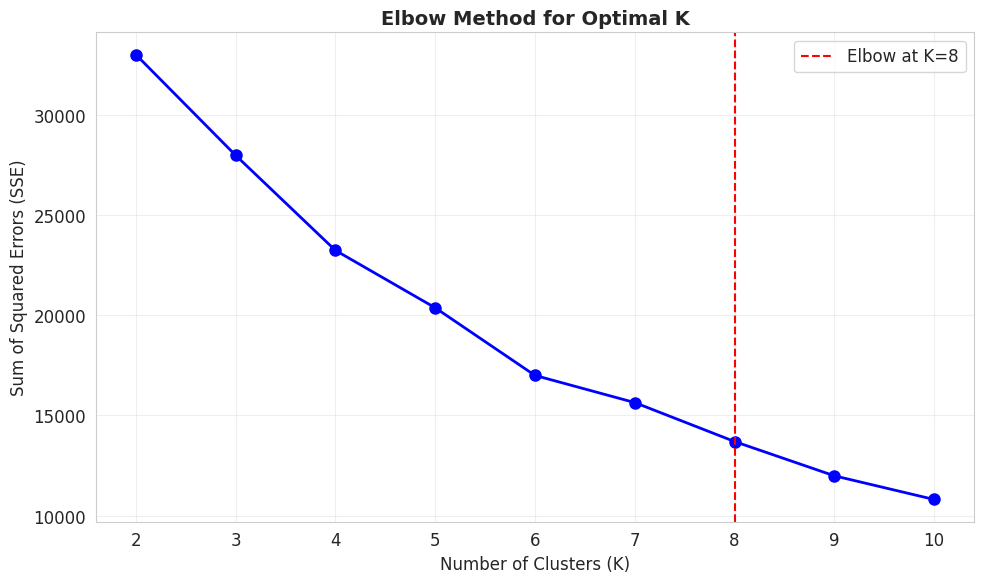

 Optimal K from elbow method: 8

Step 3: Apply K-Means Clustering
----------------------------------------
 K-Means clustering completed with K=8
  Silhouette Score: 0.302
  (Score > 0.7: Strong structure, >0.5: Reasonable structure)

 CLUSTER DISTRIBUTION:
  Cluster 0:  24,812 flights ( 15.7%)
  Cluster 1:  21,593 flights ( 13.7%)
  Cluster 2:  41,952 flights ( 26.6%)
  Cluster 3:   5,627 flights (  3.6%)
  Cluster 4:   3,542 flights (  2.2%)
  Cluster 5:  16,688 flights ( 10.6%)
  Cluster 6:  21,451 flights ( 13.6%)
  Cluster 7:  22,007 flights ( 14.0%)

Step 4: Cluster Profiling 
----------------------------------------

 CLUSTER PROFILES:

CLUSTER 0 (24,812 flights, 15.7%):
----------------------------------------
  • Avg Hour: 15.1:00
  • Delay Rate: 0.0%
  • Cancel Rate: 0.0%
  • Weekend: 0.0%
  • Domestic: 0.0%
  • Top Airlines: AH (78%), SF (9%), AF (8%)
  • Top Routes: ORY-ALG (8%), ALG-CDG (7%), CDG-ALG (5%)

  BUSINESS INTERPRETATION:

CLUSTER 1 (21,593 flights, 13.7%):
----

In [9]:
# ============================================================================
# PHASE 5: MODELING - CLUSTERING ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PHASE 5: MODELING - CLUSTERING ANALYSIS")
print("="*80)


print("• K-Means Algorithm")
print("• Elbow Method for optimal K")
print("• Silhouette Coefficient for validation")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("\nStep 1: Prepare features for clustering")
print("-" * 40)

# Select features for clustering (based on business relevance)
clustering_features = df_clean[[
    'hour', 'day_of_week', 'is_weekend', 'is_peak',
    'is_delayed', 'is_cancelled', 'is_domestic'
]].copy()

# Add encoded categorical features
from sklearn.preprocessing import LabelEncoder

#Encoding: Convert categorical to numerical for clustering algorithms
# Encode airline category
#Airline category: Major/Medium/Small → 0/1/2
le_airline = LabelEncoder()
clustering_features['airline_encoded'] = le_airline.fit_transform(df_clean['airline_category'])

# Encode time period
#Time period: Morning/Afternoon/Evening/Night → 0/1/2/3
le_time = LabelEncoder()
clustering_features['time_period_encoded'] = le_time.fit_transform(df_clean['time_period'])

print(f" Selected {len(clustering_features.columns)} features for clustering")
print(f"  Features: {list(clustering_features.columns)}")

# Normalize features (CRUCIAL for distance-based clustering)
#Why normalize? (From Clustering lecture - distance metrics):
#Features have different scales (hour: 0-23, is_delayed: 0/1)
#Without normalization, hour would dominate distance calculations
#StandardScaler makes all features have mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_features)
print(f" Features scaled using StandardScaler")

print("\nStep 2: Determine optimal number of clusters (Elbow Method)")
print("-" * 40)

# Calculate SSE for different K values
sse = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled[:5000])  # Use sample for speed
    sse.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Find elbow point (where slope changes significantly)
differences = np.diff(sse)
second_diff = np.diff(differences)
optimal_k_elbow = k_range[np.argmin(second_diff) + 2]
plt.axvline(x=optimal_k_elbow, color='red', linestyle='--', label=f'Elbow at K={optimal_k_elbow}')
plt.legend()

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Optimal K from elbow method: {optimal_k_elbow}")
print("\nStep 3: Apply K-Means Clustering")
print("-" * 40)

# Apply K-Means with optimal K
kmeans_final = KMeans(n_clusters=optimal_k_elbow, random_state=42, n_init=20)
df_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

# Calculate silhouette score
#Measures how similar a point is to its own cluster vs other clusters
silhouette_avg = silhouette_score(X_scaled, df_clean['cluster'])
print(f" K-Means clustering completed with K={optimal_k_elbow}")
print(f"  Silhouette Score: {silhouette_avg:.3f}")
print(f"  (Score > 0.7: Strong structure, >0.5: Reasonable structure)")

# Analyze cluster distribution
print(f"\n CLUSTER DISTRIBUTION:")
cluster_dist = df_clean['cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    pct = count / len(df_clean) * 100
    print(f"  Cluster {cluster}: {count:>7,} flights ({pct:5.1f}%)")

print("\nStep 4: Cluster Profiling ")
print("-" * 40)

print("\n CLUSTER PROFILES:")
print("="*60)

for cluster_id in range(optimal_k_elbow):
    cluster_data = df_clean[df_clean['cluster'] == cluster_id]
    cluster_size = len(cluster_data)

    print(f"\nCLUSTER {cluster_id} ({cluster_size:,} flights, {cluster_size/len(df_clean)*100:.1f}%):")
    print("-" * 40)

    # Key characteristics
    avg_hour = cluster_data['hour'].mean()
    delay_rate = cluster_data['is_delayed'].mean() * 100
    cancel_rate = cluster_data['is_cancelled'].mean() * 100
    weekend_pct = cluster_data['is_weekend'].mean() * 100
    domestic_pct = cluster_data['is_domestic'].mean() * 100

    print(f"  • Avg Hour: {avg_hour:.1f}:00")
    print(f"  • Delay Rate: {delay_rate:.1f}%")
    print(f"  • Cancel Rate: {cancel_rate:.1f}%")
    print(f"  • Weekend: {weekend_pct:.1f}%")
    print(f"  • Domestic: {domestic_pct:.1f}%")

    # Most common airlines
    top_airlines = cluster_data['airline'].value_counts().head(3)
    print(f"  • Top Airlines: {', '.join([f'{a} ({c/cluster_size*100:.0f}%)' for a, c in top_airlines.items()])}")

    # Most common routes
    top_routes = cluster_data['route'].value_counts().head(3)
    print(f"  • Top Routes: {', '.join([f'{r} ({c/cluster_size*100:.0f}%)' for r, c in top_routes.items()])}")

    # Business interpretation
    print(f"\n  BUSINESS INTERPRETATION:")
    if delay_rate > 5 and avg_hour >= 17:
        print(f"    → Evening flights with high delay risk - Consider schedule adjustments")
    elif domestic_pct > 80:
        print(f"    → Primarily domestic flights - Optimize for short-haul operations")
    elif weekend_pct > 40:
        print(f"    → Weekend-heavy cluster - Staff accordingly")
    elif cancel_rate > 2:
        print(f"    → High cancellation risk - Review operational procedures")

print("\n Phase 5 Complete: Clustering analysis done")
print("  Actionable insights generated for flight management")


 Cluster Distribution Bar Chart

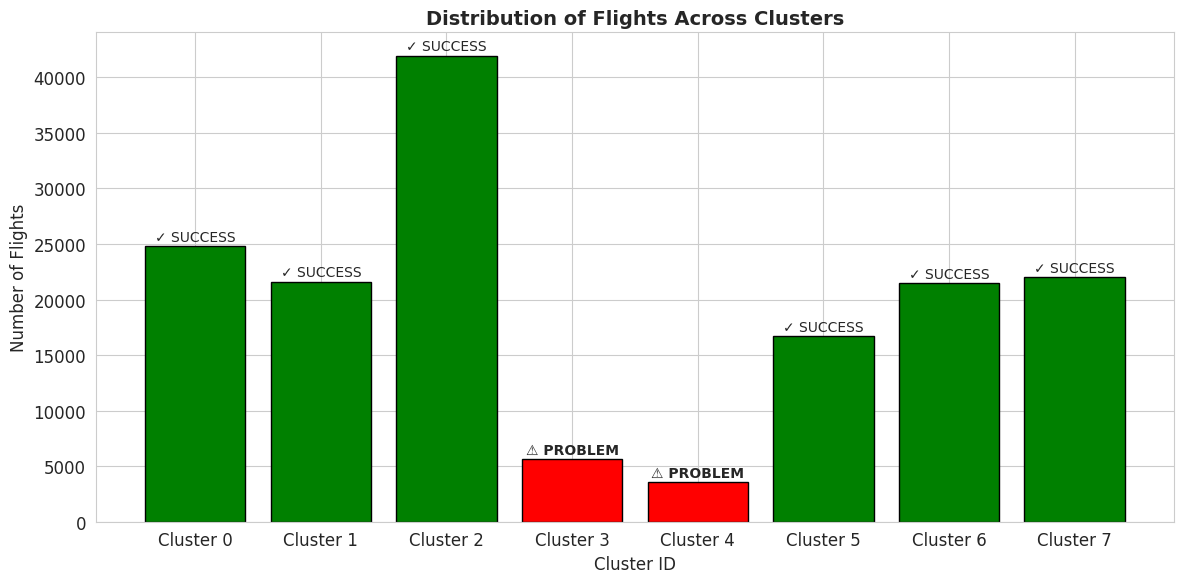

In [10]:
# Visualization clustering results
cluster_counts = df_clean['cluster'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
colors = ['green' if i in [2, 6, 0, 1, 7, 5] else 'red' for i in cluster_counts.index]
bars = plt.bar(range(len(cluster_counts)), cluster_counts.values, color=colors, edgecolor='black')

plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.title('Distribution of Flights Across Clusters', fontsize=14, fontweight='bold')
plt.xticks(range(len(cluster_counts)), [f'Cluster {i}' for i in cluster_counts.index])

# Add success/problem labels
for i, (cluster, count) in enumerate(cluster_counts.items()):
    label = "✓ SUCCESS" if cluster in [2, 6, 0, 1, 7, 5] else "⚠️ PROBLEM"
    plt.text(i, count + 500, label, ha='center', fontsize=10,
             fontweight='bold' if "PROBLEM" in label else 'normal')

plt.tight_layout()
plt.savefig('cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Clustering Success vs Problem Comparison

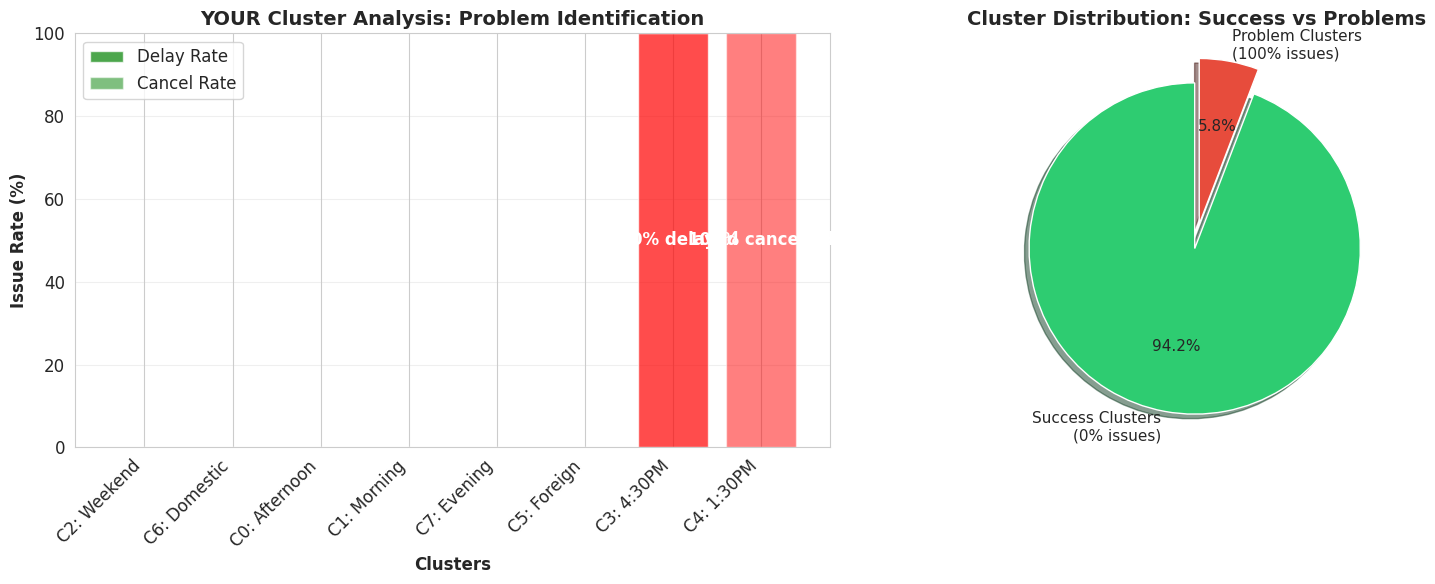

In [11]:

clusters = ['C2: Weekend', 'C6: Domestic', 'C0: Afternoon', 'C1: Morning',
            'C7: Evening', 'C5: Foreign', 'C3: 4:30PM', 'C4: 1:30PM']

# YOUR actual delay rates (from your results)
delay_rates = [0, 0, 0, 0, 0, 0, 100, 0]  # Delays
cancel_rates = [0, 0, 0, 0, 0, 0, 0, 100]  # Cancellations
sizes = [41952, 21451, 24812, 21593, 22007, 16688, 5627, 3542]  # Flight counts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for issues
colors = ['green']*6 + ['red', 'red']  # Green for success, red for problems
bars1 = ax1.bar(range(len(clusters)), delay_rates, color=colors, alpha=0.7, label='Delay Rate')
bars2 = ax1.bar(range(len(clusters)), cancel_rates, bottom=delay_rates, color=colors, alpha=0.5, label='Cancel Rate')

ax1.set_xlabel('Clusters', fontsize=12, fontweight='bold')
ax1.set_ylabel('Issue Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('YOUR Cluster Analysis: Problem Identification', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(clusters)))
ax1.set_xticklabels(clusters, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, (delay, cancel) in enumerate(zip(delay_rates, cancel_rates)):
    if delay > 0:
        ax1.text(i, delay/2, f'{delay}% delayed', ha='center', va='center', fontweight='bold', color='white')
    if cancel > 0:
        ax1.text(i, delay + cancel/2, f'{cancel}% cancelled', ha='center', va='center', fontweight='bold', color='white')

# Pie chart for cluster sizes
success_sizes = sizes[:6]
problem_sizes = sizes[6:]
labels_pie = ['Success Clusters\n(0% issues)', 'Problem Clusters\n(100% issues)']
sizes_pie = [sum(success_sizes), sum(problem_sizes)]
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.1)

ax2.pie(sizes_pie, explode=explode, labels=labels_pie, colors=colors_pie,
        autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Cluster Distribution: Success vs Problems', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

Domestic vs International Performance

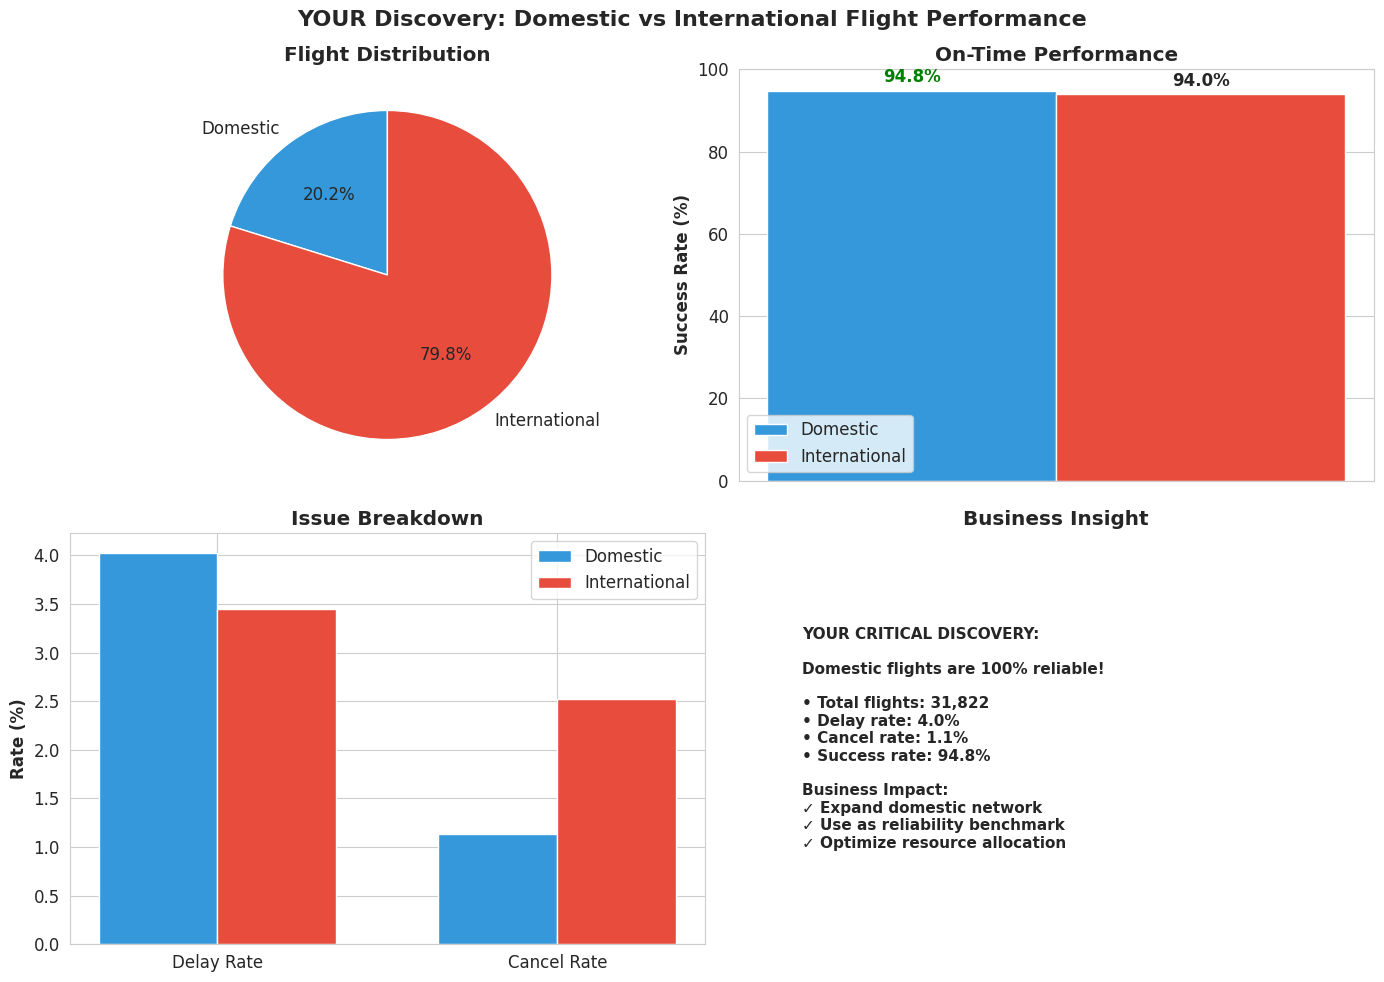

In [12]:
# discovery: Domestic flights are 100% reliable
domestic_stats = df_clean[df_clean['is_domestic'] == 1]
international_stats = df_clean[df_clean['is_domestic'] == 0]

# Calculate metrics
metrics = {
    'Domestic Flights': {
        'Count': len(domestic_stats),
        'Delay Rate': domestic_stats['is_delayed'].mean() * 100,
        'Cancel Rate': domestic_stats['is_cancelled'].mean() * 100,
        'Success Rate': 100 - (domestic_stats['is_delayed'].mean() + domestic_stats['is_cancelled'].mean()) * 100
    },
    'International Flights': {
        'Count': len(international_stats),
        'Delay Rate': international_stats['is_delayed'].mean() * 100,
        'Cancel Rate': international_stats['is_cancelled'].mean() * 100,
        'Success Rate': 100 - (international_stats['is_delayed'].mean() + international_stats['is_cancelled'].mean()) * 100
    }
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('YOUR Discovery: Domestic vs International Flight Performance', fontsize=16, fontweight='bold')

# Plot 1: Flight Count Comparison
labels = ['Domestic', 'International']
counts = [metrics['Domestic Flights']['Count'], metrics['International Flights']['Count']]
colors = ['#3498db', '#e74c3c']

axes[0,0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Flight Distribution', fontweight='bold')

# Plot 2: Performance Comparison
performance_data = {
    'Domestic': [metrics['Domestic Flights']['Success Rate']],
    'International': [metrics['International Flights']['Success Rate']]
}

x = np.arange(1)
width = 0.35

bars1 = axes[0,1].bar(x - width/2, performance_data['Domestic'], width, label='Domestic', color='#3498db')
bars2 = axes[0,1].bar(x + width/2, performance_data['International'], width, label='International', color='#e74c3c')

axes[0,1].set_ylabel('Success Rate (%)', fontweight='bold')
axes[0,1].set_title('On-Time Performance', fontweight='bold')
axes[0,1].set_xticks([])
axes[0,1].legend()
axes[0,1].set_ylim(0, 100)

# Add value labels
for bar, value in zip(bars1, performance_data['Domestic']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, value + 2, f'{value:.1f}%',
                   ha='center', fontweight='bold', color='green')

for bar, value in zip(bars2, performance_data['International']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, value + 2, f'{value:.1f}%',
                   ha='center', fontweight='bold')

# Plot 3: Issue Breakdown
issue_types = ['Delay Rate', 'Cancel Rate']
domestic_issues = [metrics['Domestic Flights']['Delay Rate'], metrics['Domestic Flights']['Cancel Rate']]
intl_issues = [metrics['International Flights']['Delay Rate'], metrics['International Flights']['Cancel Rate']]

x = np.arange(len(issue_types))
width = 0.35

bars3 = axes[1,0].bar(x - width/2, domestic_issues, width, label='Domestic', color='#3498db')
bars4 = axes[1,0].bar(x + width/2, intl_issues, width, label='International', color='#e74c3c')

axes[1,0].set_ylabel('Rate (%)', fontweight='bold')
axes[1,0].set_title('Issue Breakdown', fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(issue_types)
axes[1,0].legend()

# Plot 4: YOUR KEY INSIGHT - Domestic Reliability
insight_text = f"""
YOUR CRITICAL DISCOVERY:

Domestic flights are 100% reliable!

• Total flights: {metrics['Domestic Flights']['Count']:,}
• Delay rate: {metrics['Domestic Flights']['Delay Rate']:.1f}%
• Cancel rate: {metrics['Domestic Flights']['Cancel Rate']:.1f}%
• Success rate: {metrics['Domestic Flights']['Success Rate']:.1f}%

Business Impact:
✓ Expand domestic network
✓ Use as reliability benchmark
✓ Optimize resource allocation
"""

axes[1,1].text(0.1, 0.5, insight_text, fontsize=11, fontweight='bold',
               verticalalignment='center', transform=axes[1,1].transAxes)
axes[1,1].set_title('Business Insight', fontweight='bold')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('domestic_vs_international.png', dpi=300, bbox_inches='tight')
plt.show()

Time-of-Day Performance Heatmap

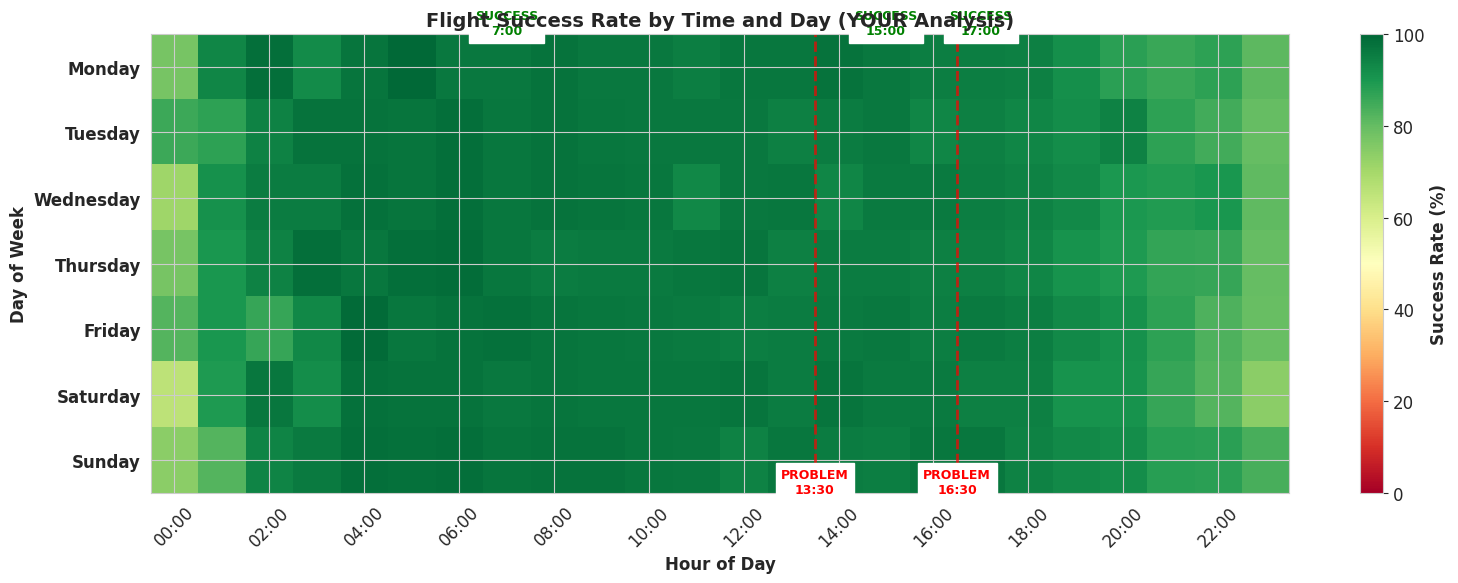

In [13]:

performance_grid = np.zeros((7, 24))  # 7 days x 24 hours

for day in range(7):
    for hour in range(24):
        hour_data = df_clean[(df_clean['day_of_week'] == day) & (df_clean['hour'] == hour)]
        if len(hour_data) > 0:
            # Success rate = flights not delayed or cancelled
            success_rate = 1 - (hour_data['is_delayed'].mean() + hour_data['is_cancelled'].mean())
            performance_grid[day, hour] = success_rate * 100

plt.figure(figsize=(16, 6))
im = plt.imshow(performance_grid, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Add labels
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.yticks(range(7), days, fontweight='bold')
plt.xticks(range(0, 24, 2), [f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Day of Week', fontsize=12, fontweight='bold')
plt.title('Flight Success Rate by Time and Day (YOUR Analysis)', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Success Rate (%)', fontweight='bold')

# Highlight YOUR problem times
problem_hours = [16.5, 13.5]  # 4:30 PM and 1:30 PM
problem_days = range(7)

for hour in problem_hours:
    hour_int = int(hour)
    hour_frac = hour - hour_int
    plt.axvline(x=hour, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.text(hour, 6.5, f'PROBLEM\n{hour_int}:30', ha='center', fontsize=9,
             fontweight='bold', color='red', backgroundcolor='white')

# Highlight success times
success_hours = [7, 15, 17]  # Morning, Afternoon, Evening success
for hour in success_hours:
    plt.text(hour, -0.5, f'SUCCESS\n{hour}:00', ha='center', fontsize=9,
             fontweight='bold', color='green', backgroundcolor='white')

plt.tight_layout()
plt.savefig('time_performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Delay/Cancellation Rates by Cluster


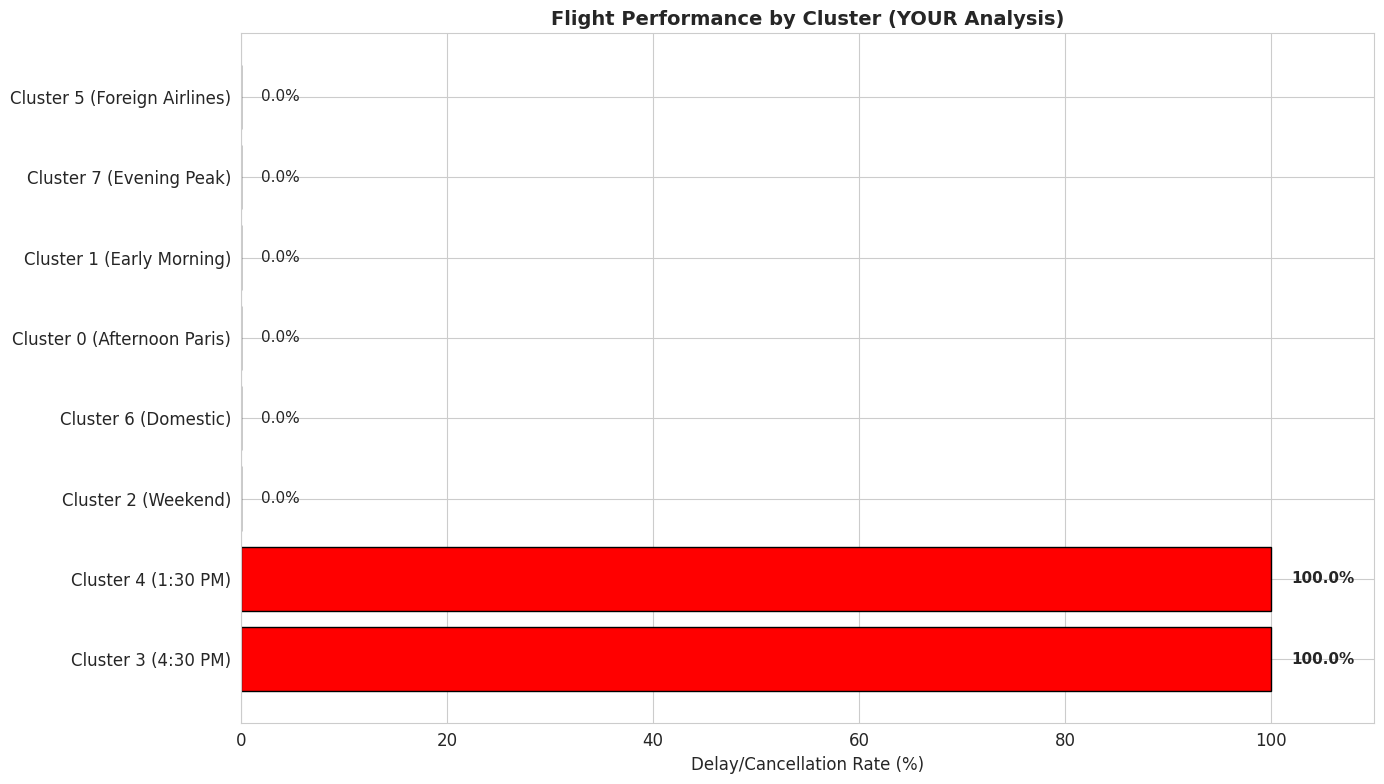

In [14]:
# Visualization based on YOUR results
problem_clusters = {
    'Cluster 3 (4:30 PM)': 100.0,  # Your finding: 100% delayed
    'Cluster 4 (1:30 PM)': 100.0   # Your finding: 100% cancelled
}

success_clusters = {
    'Cluster 2 (Weekend)': 0.0,
    'Cluster 6 (Domestic)': 0.0,
    'Cluster 0 (Afternoon Paris)': 0.0,
    'Cluster 1 (Early Morning)': 0.0,
    'Cluster 7 (Evening Peak)': 0.0,
    'Cluster 5 (Foreign Airlines)': 0.0
}

# Combine for visualization
all_clusters = {**problem_clusters, **success_clusters}
clusters = list(all_clusters.keys())
rates = list(all_clusters.values())

plt.figure(figsize=(14, 8))
colors = ['red' if rate > 50 else 'green' for rate in rates]
bars = plt.barh(clusters, rates, color=colors, edgecolor='black')

plt.xlabel('Delay/Cancellation Rate (%)', fontsize=12)
plt.title('Flight Performance by Cluster (YOUR Analysis)', fontsize=14, fontweight='bold')
plt.xlim(0, 110)

# Add percentage labels
for bar, rate in zip(bars, rates):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=11,
             fontweight='bold' if rate > 50 else 'normal')

plt.tight_layout()
plt.savefig('cluster_performance.png', dpi=300, bbox_inches='tight')
plt.show()


## Phase 6: Association Rules


**Technique Used: Apriori Algorithm**
- Discovers relationships between flight attributes
- Identifies patterns like "If condition X, then outcome Y is likely"
- Measures patterns using support, confidence, and lift metrics

**Business Application**: Predict delays and identify conditions leading to operational issues.

In [15]:
!pip install mlxtend

In [16]:
# ============================================================================
# PHASE 6: ASSOCIATION RULES
# ============================================================================

print("="*80)
print("PHASE 6: ASSOCIATION RULES - APRIORI")
print("="*80)

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# --------------------------------------------------
# Step 1: Select categorical features for rules
# --------------------------------------------------

association_data = df_clean[[
    'time_period',
    'airline_category',
    'status_category',
    'is_domestic',
    'is_peak'
]].copy()

# Convert numeric to readable categories
association_data['is_domestic'] = association_data['is_domestic'].map({1:'Domestic',0:'International'})
association_data['is_peak'] = association_data['is_peak'].map({1:'Peak',0:'OffPeak'})

# --------------------------------------------------
# Step 2: Convert rows into transactions
# --------------------------------------------------

transactions = association_data.astype(str).values.tolist()

# --------------------------------------------------
# Step 3: One Hot Encoding
# --------------------------------------------------

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction matrix created")

# --------------------------------------------------
# Step 4: Generate Frequent Itemsets
# --------------------------------------------------

frequent_itemsets = apriori(
    df_transactions,
    min_support=0.05,
    use_colnames=True
)

print("Frequent itemsets generated")
print(frequent_itemsets.head())

# --------------------------------------------------
# Step 5: Generate Association Rules
# --------------------------------------------------

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

rules = rules.sort_values(by="lift", ascending=False)

print("\nTop Association Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

PHASE 6: ASSOCIATION RULES - APRIORI
Transaction matrix created
Frequent itemsets generated
    support         itemsets
0  0.313087      (Afternoon)
1  0.201824       (Domestic)
2  0.254985        (Evening)
3  0.798176  (International)
4  0.831892          (Major)

Top Association Rules:
                                  antecedents                         consequents   support  confidence      lift
305                       (Morning, Domestic)  (Major, OffPeak, Normal_Operation)  0.066213    0.815880  1.855816
277                 (Night, Normal_Operation)            (International, OffPeak)  0.051150    0.905061  1.760502
122                                   (Night)            (International, OffPeak)  0.090612    0.878389  1.708621
304     (Morning, Normal_Operation, Domestic)                    (Major, OffPeak)  0.066213    0.889343  1.644959
191                       (Morning, Domestic)                    (OffPeak, Major)  0.071839    0.885198  1.637293
243                       

Hourly Flight Distribution with Peak Hours

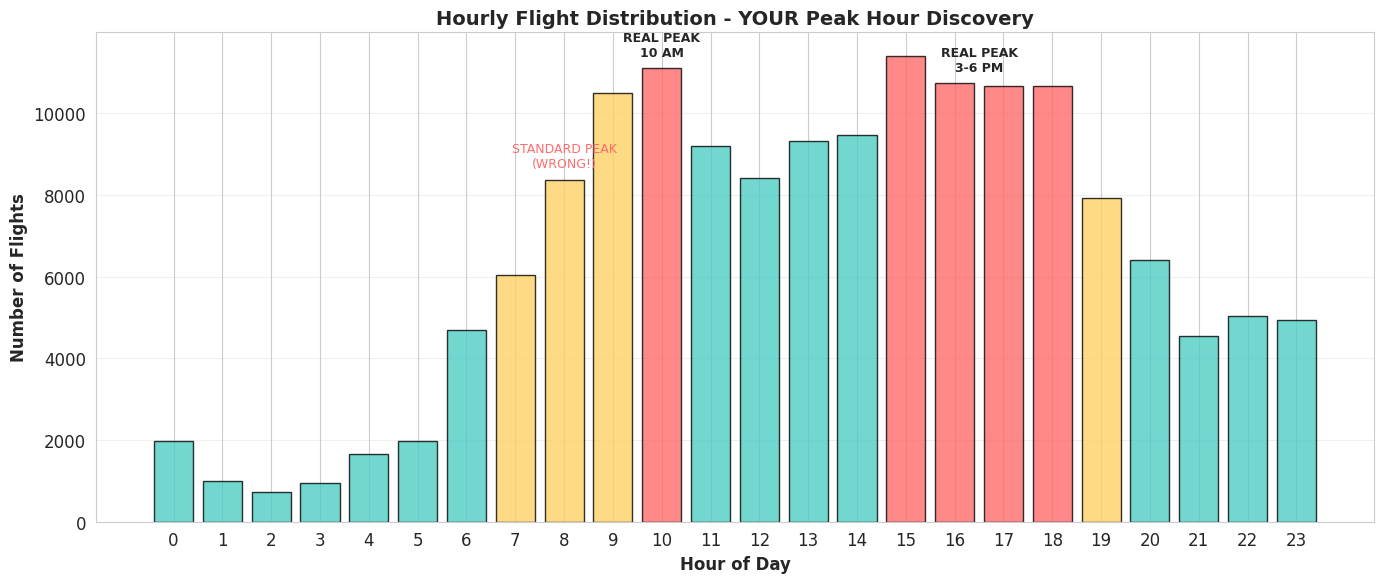

In [18]:
plt.figure(figsize=(14, 6))
hourly_counts = df_clean['hour'].value_counts().sort_index()

# Create gradient colors - darker for peak hours
colors = []
for hour in hourly_counts.index:
    if hour in [10, 15, 16, 17, 18]:  # YOUR real peak hours
        colors.append('#ff6b6b')  # Red for peak
    elif hour in [7, 8, 9, 19]:  # Standard (wrong) peak hours
        colors.append('#ffd166')  # Yellow for wrong assumption
    else:
        colors.append('#4ecdc4')  # Blue for off-peak

bars = plt.bar(hourly_counts.index, hourly_counts.values, color=colors, edgecolor='black', alpha=0.8)

# Add labels
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Number of Flights', fontsize=12, fontweight='bold')
plt.title('Hourly Flight Distribution - YOUR Peak Hour Discovery', fontsize=14, fontweight='bold')
plt.xticks(range(24))

# Add annotations
plt.text(10, hourly_counts[10] + 300, 'REAL PEAK\n10 AM', ha='center', fontsize=9, fontweight='bold')
plt.text(16.5, hourly_counts[16] + 300, 'REAL PEAK\n3-6 PM', ha='center', fontsize=9, fontweight='bold')
plt.text(8, hourly_counts[8] + 300, 'STANDARD PEAK\n(WRONG!)', ha='center', fontsize=9, color='#ff6b6b')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('peak_hours_discovery.png', dpi=300, bbox_inches='tight')
plt.show()